# Modeling Final & SHAP 분석
### 1. 최종 모델인 CatBoost 단독 모델과 최적 파라미터, threshold를 사용한 최종 모델링
### 2. 비선형 모델인 CatBoost의 설명력을 보완하기 위한 SHAP 분석

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import shap

In [2]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

In [3]:
# =========================
# 데이터 로드
# =========================
DATA_DIR = Path('../Data')
train_df = pd.read_csv(DATA_DIR / "train_selection_top30.csv")
test_df = pd.read_csv(DATA_DIR / "test_selection_top30.csv")

target_col = "fraud"

X = train_df.drop(columns=[target_col]).copy()
y = train_df[target_col].copy()
X_test = test_df.copy()

print("Train X shape:", X.shape)
print("Train y shape:", y.shape)
print("Test X shape :", X_test.shape)
print("Positive ratio:", round(y.mean(), 4))

Train X shape: (18000, 30)
Train y shape: (18000,)
Test X shape : (12000, 30)
Positive ratio: 0.1582


In [4]:
# =========================
# 최적 CatBoost 파라미터
# =========================
cat_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 300,
    "learning_rate": 0.03,
    "depth": 4,
    "l2_leaf_reg": 5,
    "subsample": 1.0,
    "bootstrap_type": "Bernoulli",
    "random_seed": 2542,
    "auto_class_weights": "Balanced",
    "verbose": -1
}

In [5]:
# threshold 기준으로 이진 분류 성능 지표(ROC-AUC, PR-AUC, F1 등)를 계산
def evaluate_scores(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0)
    }

# 상위 top_ratio 비율 내에서 실제 양성(fraud)을 얼마나 잘 찾았는지(Recall@K) 계산
def recall_at_k(y_true, y_prob, top_ratio=0.10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    n_top = max(1, int(len(y_prob) * top_ratio))
    top_idx = np.argsort(y_prob)[::-1][:n_top]

    total_positive = y_true.sum()
    if total_positive == 0:
        return 0.0

    return y_true[top_idx].sum() / total_positive

# 상위 top_ratio 비율 내에서 실제 양성(fraud)을 얼마나 잘 찾았는지(Recall@K) 계산
def precision_at_k(y_true, y_prob, top_ratio=0.10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    n_top = max(1, int(len(y_prob) * top_ratio))
    top_idx = np.argsort(y_prob)[::-1][:n_top]

    return y_true[top_idx].mean()

# 상위 top_ratio 구간의 precision이 전체 평균 대비 몇 배 높은지(Lift@K) 계산
def lift_at_k(y_true, y_prob, top_ratio=0.10):
    base_rate = np.mean(y_true)
    p_at_k = precision_at_k(y_true, y_prob, top_ratio)

    if base_rate == 0:
        return 0.0

    return p_at_k / base_rate

In [6]:
def run_catboost_oof_and_test(X, y, X_test, cat_params, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_scores = []
    importance_list = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n{'='*20} Fold {fold} {'='*20}")

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        model = CatBoostClassifier(**cat_params)

        model.fit(
            X_train, y_train,
            eval_set=(X_valid, y_valid),
            verbose=False
        )

        valid_prob = model.predict_proba(X_valid)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        oof_pred[valid_idx] = valid_prob
        test_pred += test_prob / n_splits

        fold_result = {
            "fold": fold,
            "roc_auc": roc_auc_score(y_valid, valid_prob),
            "pr_auc": average_precision_score(y_valid, valid_prob)
        }
        fold_scores.append(fold_result)

        fold_importance = pd.DataFrame({
            "feature": X.columns,
            "importance": model.get_feature_importance(),
            "fold": fold
        })
        importance_list.append(fold_importance)

        print(f"ROC-AUC: {fold_result['roc_auc']:.4f} | PR-AUC: {fold_result['pr_auc']:.4f}")

    fold_score_df = pd.DataFrame(fold_scores)
    importance_df = pd.concat(importance_list, axis=0, ignore_index=True)

    return oof_pred, test_pred, fold_score_df, importance_df

In [7]:
oof_pred, test_pred, fold_score_df, importance_df = run_catboost_oof_and_test(
    X=X,
    y=y,
    X_test=X_test,
    cat_params=cat_params,
    n_splits=5,
    random_state=42
)


==================== Fold 1 ====================
ROC-AUC: 0.6829 | PR-AUC: 0.2732

==================== Fold 2 ====================
ROC-AUC: 0.7139 | PR-AUC: 0.3235

==================== Fold 3 ====================
ROC-AUC: 0.7052 | PR-AUC: 0.2990

==================== Fold 4 ====================
ROC-AUC: 0.7250 | PR-AUC: 0.3120

==================== Fold 5 ====================
ROC-AUC: 0.7131 | PR-AUC: 0.3074


In [8]:
# OOF 예측 기준 전체 성능과 CV 통계 요약을 출력
oof_result = evaluate_scores(y, oof_pred, threshold=0.5)

print("=== OOF Final Result (threshold=0.5) ===")
print(oof_result)

print("\n=== CV Summary ===")
print(fold_score_df.describe().round(4))

=== OOF Final Result (threshold=0.5) ===
{'roc_auc': 0.7076645099323114, 'pr_auc': 0.2992161715418113, 'f1': 0.36450048496605236, 'precision': 0.2518091664433128, 'recall': 0.6597612359550562}

=== CV Summary ===
         fold  roc_auc  pr_auc
count  5.0000   5.0000  5.0000
mean   3.0000   0.7080  0.3030
std    1.5811   0.0157  0.0189
min    1.0000   0.6829  0.2732
25%    2.0000   0.7052  0.2990
50%    3.0000   0.7131  0.3074
75%    4.0000   0.7139  0.3120
max    5.0000   0.7250  0.3235


In [16]:
threshold_rows = []
scores = evaluate_scores(y, oof_pred, threshold=0.45)
threshold_rows.append({
    "threshold": round(0.45, 2),
    "roc_auc": scores["roc_auc"],
    "pr_auc": scores["pr_auc"],
    "f1": scores["f1"],
    "precision": scores["precision"],
    "recall": scores["recall"]
})
threshold_df = pd.DataFrame(threshold_rows).reset_index(drop=True)

print("=== Best Threshold ===")
threshold_df.round(4)

=== Best Threshold ===


,threshold,roc_auc,pr_auc,f1,precision,recall
0,0.45,0.7077,0.2992,0.3565,0.2313,0.7763


In [17]:
topk_ratios = [0.01, 0.03, 0.05, 0.10, 0.20]

topk_rows = []

for r in topk_ratios:
    topk_rows.append({
        "top_ratio": r,
        "recall_at_k": recall_at_k(y, oof_pred, r),
        "precision_at_k": precision_at_k(y, oof_pred, r),
        "lift_at_k": lift_at_k(y, oof_pred, r)
    })

topk_df = pd.DataFrame(topk_rows)
topk_df.round(4)

,top_ratio,recall_at_k,precision_at_k,lift_at_k
0,0.01,0.0249,0.3944,2.4930
1,0.03,0.0804,0.4241,2.6802
2,0.05,0.1320,0.4178,2.6404
3,0.10,0.2279,0.3606,2.2788
4,0.20,0.3954,0.3128,1.9768


In [19]:
# Top-K 전략: 운영 환경에서는 조사 자원이 제한되어 있으므로, 
#            예측 확률 상위 10%를 우선 조사 대상으로 선정
top10_threshold = np.quantile(oof_pred, 0.90)

y_pred_top10 = (oof_pred >= top10_threshold).astype(int)

selected_ratio = y_pred_top10.mean()

top10_metrics = {
    "threshold": top10_threshold,
    "selected_ratio": selected_ratio,
    "precision": precision_score(y, y_pred_top10, zero_division=0),
    "recall": recall_score(y, y_pred_top10, zero_division=0),
    "f1": f1_score(y, y_pred_top10, zero_division=0)
}

print("=== Top 10% Cutoff Metrics ===")
print(top10_metrics)

=== Top 10% Cutoff Metrics ===
{'threshold': np.float64(0.6606554405808436), 'selected_ratio': np.float64(0.1), 'precision': 0.3605555555555556, 'recall': 0.22787921348314608, 'f1': 0.27925989672977625}


## Feature Importance 분석

In [20]:
importance_summary = (
    importance_df
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_summary["rank"] = np.arange(1, len(importance_summary) + 1)

importance_summary.head(20)

,feature,importance,rank
0,accident_parking,20.409095,1
1,age_of_driver_sq,11.157889,2
2,high_education_ind,9.847179,3
3,age_of_driver,7.576655,4
4,witness_present_ind,6.936176,5
5,marital_status,4.835532,6
6,address_change_ind,4.472051,7
7,zip_rate_x_accident_highway,4.000590,8
8,claim_year,2.690035,9
9,age_of_driver_x_safty_rating,2.294495,10


In [21]:
# 최종 모델 학습
final_model = CatBoostClassifier(**cat_params)

final_model.fit(X, y, verbose=False)

final_test_pred = final_model.predict_proba(X_test)[:, 1]

In [29]:
# test 데이터셋의 fraud 확률 저장
test_pred_df = pd.DataFrame({
    "pred_proba": final_test_pred
})

test_pred_df.to_csv(DATA_DIR / "test_pred_proba_catboost_final.csv", index=False)

In [31]:
# threshold를 적용한 최종 분류 결과
# best_threshold = float(best_thr_row["threshold"])
test_pred_label = (final_test_pred >= 0.45).astype(int)

test_label_df = pd.DataFrame({
    "pred_proba": final_test_pred,
    "pred_label": test_pred_label
})

test_label_df.to_csv(DATA_DIR / "test_pred_label_catboost_final.csv", index=False)

In [32]:
# 상위 10% 위험 고객만 따로 정리 (Top-K 전략)
top10_cutoff_test = np.quantile(final_test_pred, 0.90)

top10_candidates = pd.DataFrame({
    "pred_proba": final_test_pred
})

top10_candidates["is_top10pct"] = (top10_candidates["pred_proba"] >= top10_cutoff_test).astype(int)
top10_candidates = top10_candidates.sort_values("pred_proba", ascending=False).reset_index(drop=True)

top10_candidates.to_csv(DATA_DIR / "test_top10pct_candidates_catboost_final.csv", index=False)

In [33]:
# test 데이터 불러오기
test = pd.read_csv(DATA_DIR / "test_2025.csv")

# submission 생성
submission = pd.DataFrame({
    "claim_number": test["claim_number"],
    "fraud": test_pred_label
})

# 저장
submission.to_csv(DATA_DIR / "submission.csv", index=False)

## Final Model Summary

In [35]:
print("===== Final CatBoost Model Summary =====")
print("Parameters:", cat_params)

print("\n===== OOF Metrics (threshold=0.5) =====")
print(pd.Series(oof_result))

print("\n===== Best Threshold=====")
print(threshold_df)

print("\n===== Top-K Performance =====")
print(topk_df.round(4))

print("\n===== Top 20 Feature Importance =====")
print(importance_summary.head(20))

===== Final CatBoost Model Summary =====
Parameters: {'loss_function': 'Logloss', 'eval_metric': 'AUC', 'iterations': 300, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli', 'random_seed': 2542, 'auto_class_weights': 'Balanced', 'verbose': -1}

===== OOF Metrics (threshold=0.5) =====
roc_auc      0.707665
pr_auc       0.299216
f1           0.364500
precision    0.251809
recall       0.659761
dtype: float64

===== Best Threshold=====
   threshold   roc_auc    pr_auc        f1  precision    recall
0       0.45  0.707665  0.299216  0.356469   0.231349  0.776334

===== Top-K Performance =====
   top_ratio  recall_at_k  precision_at_k  lift_at_k
0       0.01       0.0249          0.3944     2.4930
1       0.03       0.0804          0.4241     2.6802
2       0.05       0.1320          0.4178     2.6404
3       0.10       0.2279          0.3606     2.2788
4       0.20       0.3954          0.3128     1.9768

===== Top 20 Feature Importance ==

## SHAP 분석

In [36]:
# SHAP 계산용 샘플
shap_sample_size = min(3000, len(X))
X_shap = X.sample(shap_sample_size, random_state=42).copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (3000, 30)


In [37]:
# SHAP 값 계산
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# binary classification에서 보통 ndarray로 나옴
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(3000, 30)


In [38]:
# 전역 중요도 테이블
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(shap_importance.head(20))

                        feature  mean_abs_shap
0              accident_parking       0.340784
1            high_education_ind       0.234746
2            address_change_ind       0.156946
3              age_of_driver_sq       0.152556
4                marital_status       0.151857
5           witness_present_ind       0.132419
6                 age_of_driver       0.121837
7                    claim_year       0.108447
8   zip_rate_x_accident_highway       0.091603
9   female_x_zip_fraud_rate_oof       0.044003
10           unstable_lifestyle       0.040184
11              no_verification       0.038478
12      female_x_witness_absent       0.038364
13                 liab_prct_sq       0.034877
14               witness_absent       0.031025
15         zip_rate_x_is_female       0.030675
16            safety_risk_score       0.030597
17     safty_rating_x_liab_prct       0.030397
18           female_x_liab_prct       0.028930
19   vehicle_weight_x_liab_prct       0.025855


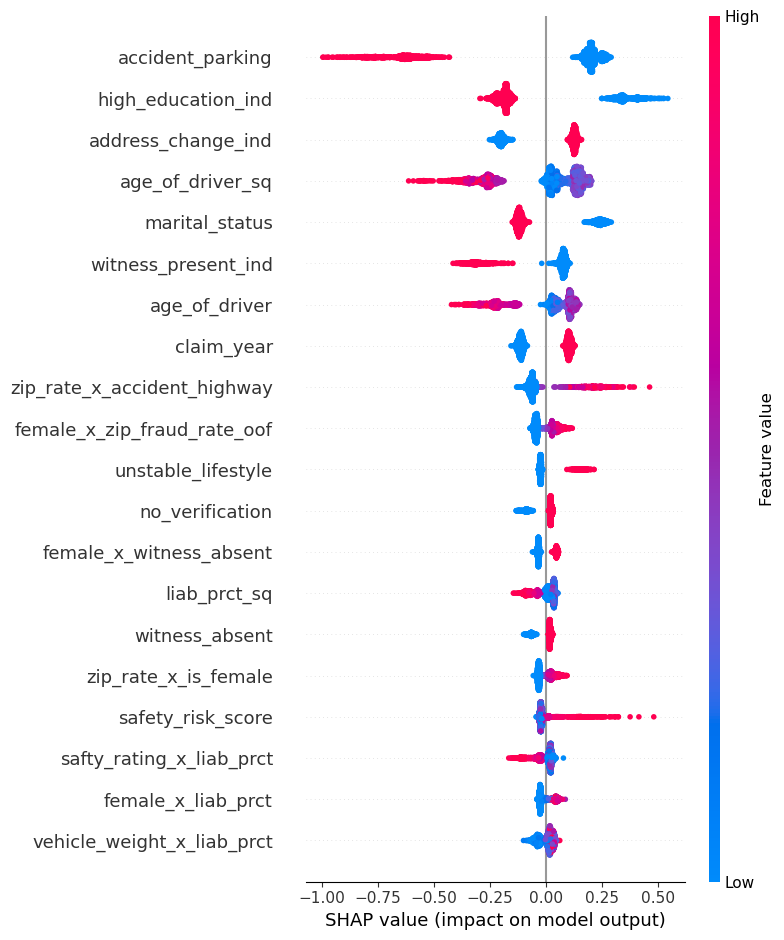

In [39]:
# SHAP summary plot
shap.summary_plot(shap_values, X_shap)

In [40]:
# 상위 feature
top_features = shap_importance["feature"].head(10).tolist()
print(top_features)

['accident_parking', 'high_education_ind', 'address_change_ind', 'age_of_driver_sq', 'marital_status', 'witness_present_ind', 'age_of_driver', 'claim_year', 'zip_rate_x_accident_highway', 'female_x_zip_fraud_rate_oof']


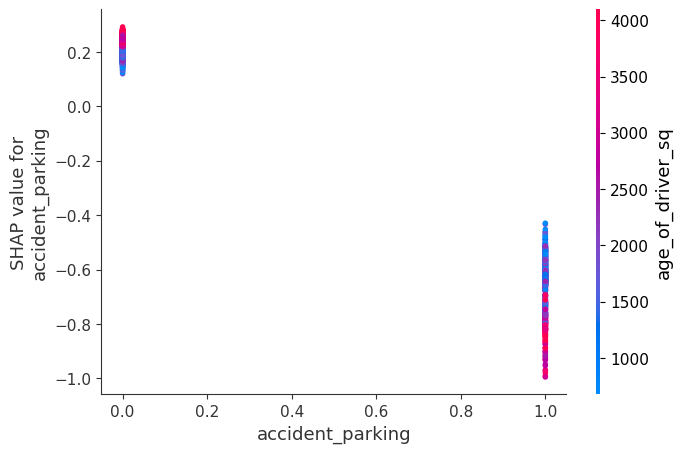

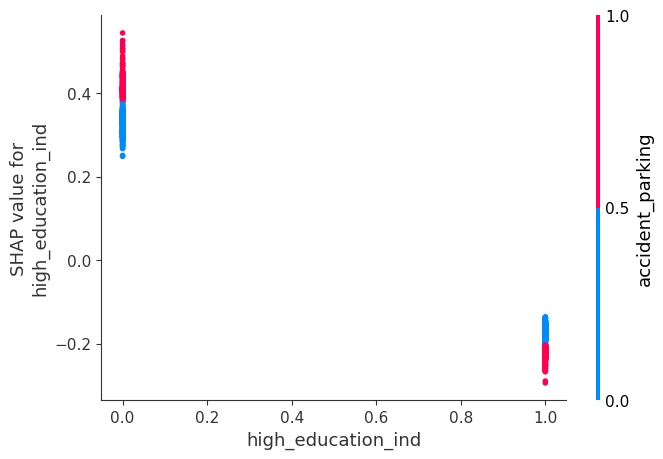

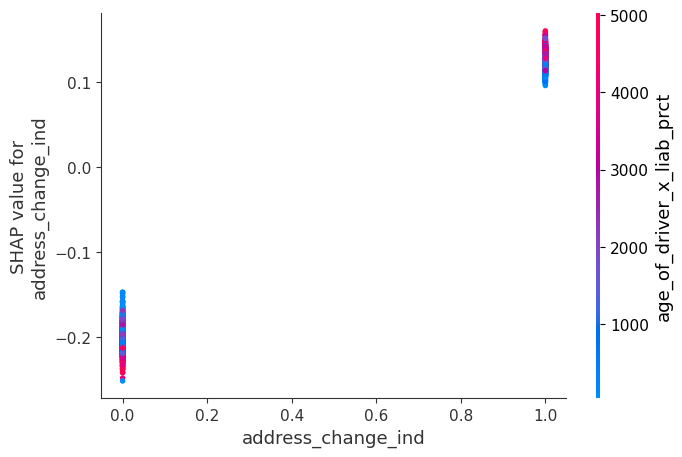

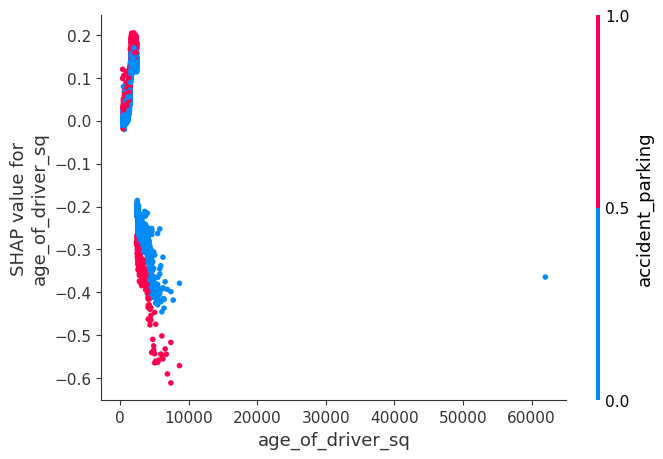

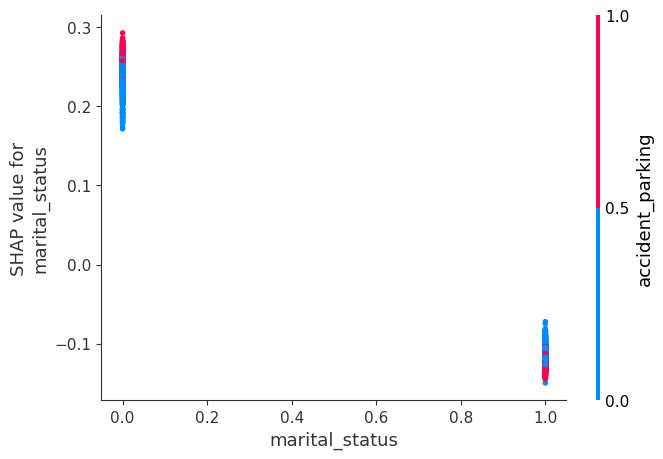

In [41]:
# 상위 5개 피처 dependence plot
for feat in top_features[:5]:
    shap.dependence_plot(feat, shap_values, X_shap)

In [42]:
# 설명용 base value
base_value = explainer.expected_value
print("Base value:", base_value)

Base value: -0.01782506557328801


In [43]:
# 상위 위험 sample 1개 SHAP 해석
train_pred_df = X.copy()
train_pred_df["fraud"] = y.values
train_pred_df["pred_proba"] = final_model.predict_proba(X)[:, 1]
train_pred_df["orig_idx"] = X.index

train_pred_df = train_pred_df.sort_values("pred_proba", ascending=False).reset_index(drop=True)

top_orig_idx = train_pred_df.loc[0, "orig_idx"]
x_one = X.loc[[top_orig_idx]].copy()

shap_one = explainer.shap_values(x_one)

shap_one_df = pd.DataFrame({
    "feature": x_one.columns,
    "feature_value": x_one.iloc[0].values,
    "shap_value": shap_one[0]
}).sort_values("shap_value", ascending=False).reset_index(drop=True)

print(shap_one_df.head(10))   # fraud 확률을 올린 요인
print(shap_one_df.tail(10))   # fraud 확률을 내린 요인

               feature  feature_value  shap_value
0    safety_risk_score           95.0    0.361749
1   high_education_ind            0.0    0.351787
2         safty_rating            5.0    0.311425
3       marital_status            0.0    0.272204
4     age_of_driver_sq         1764.0    0.154748
5     accident_parking            0.0    0.123091
6        age_of_driver           42.0    0.117729
7   address_change_ind            1.0    0.117425
8  witness_present_ind            0.0    0.093282
9      age_over_safety            7.0    0.092575
                           feature  feature_value  shap_value
20                    liab_prct_sq   2.601000e+03    0.022326
21                 day_of_week_sin   9.749279e-01    0.020785
22                 day_of_week_cos  -2.225209e-01    0.012302
23      vehicle_weight_x_liab_prct   1.508664e+06    0.009510
24                   vehicle_price   3.379337e+04    0.006363
25                 day_of_week_num   2.000000e+00   -0.000504
26  payout_to_in

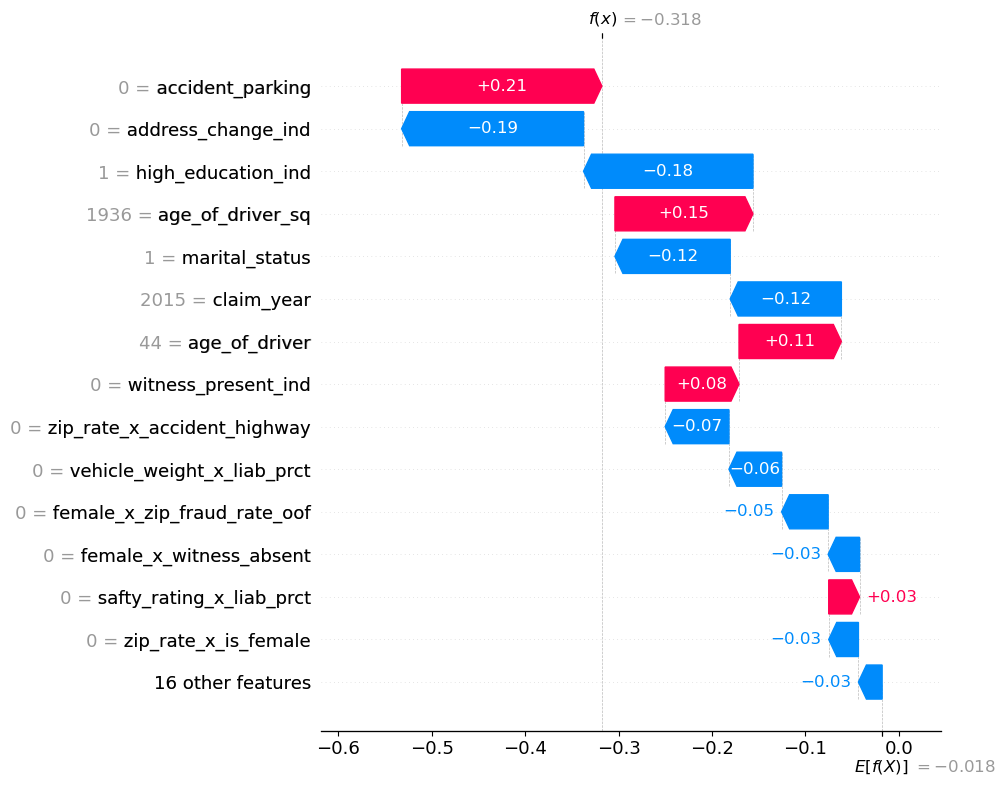

In [44]:
# waterfall plot
sample_pos = 0  # X_shap 안에서 첫 번째 샘플

shap_exp = shap.Explanation(
    values=shap_values[sample_pos],
    base_values=base_value,
    data=X_shap.iloc[sample_pos],
    feature_names=X_shap.columns.tolist()
)

shap.plots.waterfall(shap_exp, max_display=15)

## Feature Importance & SHAP 결과 해석

### 1. Feature Importance 결과

CatBoost 기반 Feature Importance 분석 결과,  
모델은 `accident_parking`, `age_of_driver_sq`, `high_education_ind`, `age_of_driver`, `witness_present_ind` 등의 변수를 가장 중요한 변수로 활용하고 있는 것으로 나타났다.

특히 `accident_parking`이 가장 높은 중요도를 보였으며, 이는 사고 유형이 fraud 판단에 핵심적인 역할을 한다는 것을 의미한다. 또한 `age_of_driver` 및 `age_of_driver_sq`와 같은 비선형 변수가 상위에 포함된 점은, 단순 연령보다 특정 구간에서의 패턴이 더 중요하게 작용함을 시사한다.

---

### 2. SHAP 기반 해석 (모델 의사결정 구조)

SHAP summary plot을 통해 각 변수의 영향 방향과 크기를 분석한 결과, 다음과 같은 패턴이 확인되었다.

#### (1) 사고 유형 및 행동 기반 변수

- `accident_parking` 값이 높은 경우 SHAP 값이 음수 방향으로 나타나 fraud 확률을 낮추는 경향을 보였다.  
  → 즉, 단순 주차 사고는 정상 사고일 가능성이 높음을 의미한다.

- `witness_present_ind`는 값이 클수록 fraud 확률을 낮추는 방향으로 작용하였다.  
  → 증인이 존재하는 경우 사고 신뢰도가 높다고 판단됨

- 반대로 `no_verification`, `witness_absent`와 같은 변수는 fraud 확률을 증가시키는 방향으로 작용하였다.  
  → 검증 부족 및 증인 부재는 주요 fraud 신호로 작용

---

#### (2) 사회·인구통계적 변수

- `high_education_ind` 및 `marital_status`는 값이 높을수록 fraud 확률을 감소시키는 경향을 보였다.  
  → 사회적 안정성이 높은 집단일수록 fraud 발생 가능성이 낮음

- `address_change_ind`는 값이 높을수록 fraud 확률을 증가시키는 방향으로 작용하였다.  
  → 잦은 주소 변경은 위험 신호로 해석됨

---

#### (3) 연령 및 비선형 패턴

- `age_of_driver`와 `age_of_driver_sq`는 특정 구간에서 fraud 확률을 감소시키는 패턴을 보였으며,  
  → 연령에 따른 비선형 효과가 존재함을 확인할 수 있다.

---

#### (4) 지역 및 환경 변수

- `zip_rate_x_accident_highway` 및 `female_x_zip_fraud_rate_oof`와 같은 지역 기반 변수는 값이 클수록 fraud 확률을 증가시키는 경향을 보였다.  
  → 특정 지역에서 fraud 발생 확률이 높다는 것을 의미

---

#### (5) 상호작용(Interaction) 변수

- `safety_rating_x_liab_prct`, `age_of_driver_x_safety_rating` 등 interaction 변수들이 중요한 역할을 수행하였다.  
  → 단일 변수보다 변수 간 조합이 fraud 판단에 더 큰 영향을 미침

---

### 3. 종합 해석

전체적으로 모델은 다음과 같은 기준으로 fraud를 판단하고 있는 것으로 나타났다:

#### 정상 패턴
- 증인이 존재
- 단순 사고 유형
- 사회적 안정성 높은 특성

#### 비정상 패턴
- 증인 부재 및 검증 부족
- 주소 변경 이력 존재
- 특정 지역 및 환경 조건
- 비정상적인 변수 조합

---

### 결론

**본 모델은 단순 변수 값이 아닌, “행동 기반 신호 + 환경 요인 + 변수 간 상호작용”을 종합적으로 활용하여 fraud를 탐지하는 구조를 가진다.**